# Project 1 - Supervised Learning


Dataset available at https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

## Phase 1 — Data loading and exploratory analysis

### Imports and dataset loading
Load the dataset via `ucimlrepo` and inspect its basic structure before any preprocessing.

In [ ]:
pip install ucimlrepo

In [ ]:
# Load features and target as separate dataframes, then concatenate them
# into a single `df` for exploratory analysis
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# fetch dataset
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468)

# data (as pandas dataframes)
X = online_shoppers_purchasing_intention_dataset.data.features
y = online_shoppers_purchasing_intention_dataset.data.targets
frames = [X, y]

df = pd.concat(frames, axis=1)

# metadata
print(online_shoppers_purchasing_intention_dataset.metadata)

# variable information
print(online_shoppers_purchasing_intention_dataset.variables)


{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Revenue'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5F88Q', 'creators': ['C. Sakar', 'Yomi Kastro'], 'intro_paper': {'ID': 367, 'type': 'NATIVE', 'title': 'Real-time prediction of online shoppers’ pur

In [ ]:
# Basic structural checks: first rows, shape, columns, dtypes, summary statistics,
# and class distribution of the target
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# Basic structural checks: shape
df.shape

(12330, 18)

In [ ]:
# Basic structural checks: columns
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [ ]:
# Basic structural checks: dtypes
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
# Basic structural checks: summary statistics
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [ ]:
# Basic structural checks: class distribution of the target
display(df['Revenue'].value_counts())
val = df['Revenue'].sum()
print(val / len(df['Revenue']) * 100, "%")

Revenue
False    10422
True      1908
Name: count, dtype: int64

15.474452554744525 %


## Phase 2 — Splitting, outlier analysis, preprocessing


### Train/test split
Stratified 80/20 split (`random_state=42`) to preserve the 15.5% positive-class ratio in both sets. The test set is held out and only used for the final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train = y_train.squeeze()
y_test = y_test.squeeze()
print(len(X_train))
print(len(X_test))

val1 = y_test.sum()
print(val1 / len(y_test) * 100, "%")

val2 = y_train.sum()
print(val2 / len(y_train) * 100, "%")


9864
2466
15.49067315490673 %
15.470397404703974 %


### Outlier analysis
Duration features are heavily right-skewed: some sessions last much longer than the third quartile. We apply the IQR rule with a **2.5 × IQR** threshold (more conservative than the standard 1.5) to quantify how many rows would be flagged, and then check the purchase rate among those rows before deciding whether to keep or remove them.

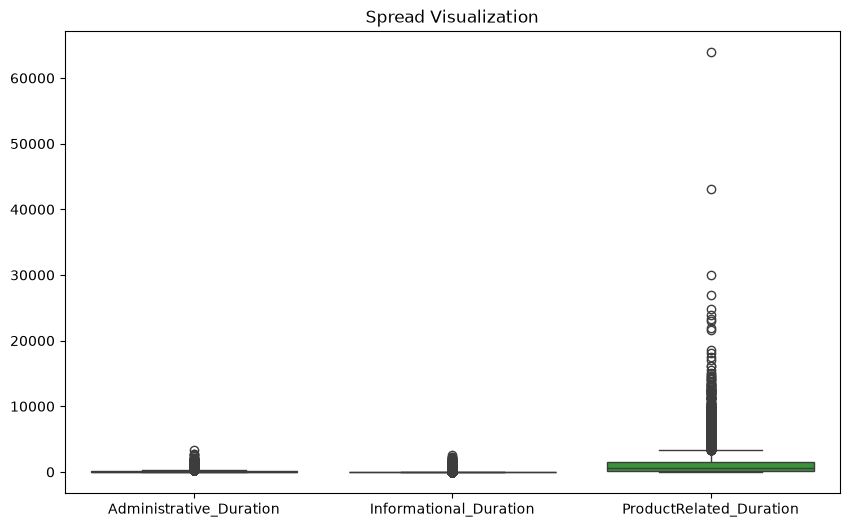

3398.75


In [ ]:
# Visualise the spread of the three duration features on the full dataset
# No filtering is applied here: this is only EDA
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data = df[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']])
plt.title("Spread Visualization")
plt.show()
print(df['Administrative_Duration'].max())

The IQR method identifies values outside `[Q1 − k·IQR, Q3 + k·IQR]`. We use `k = 2.5` to be more conservative than the standard 1.5, which would flag too many real sessions as outliers. The rule is applied to `X_train` only, to avoid using test data during analysis.

In [ ]:
# Compute IQR-based outlier bounds on the training set (2.5 * IQR, more
# conservative than the standard 1.5 * IQR). We only compute them, we do
# not filter the data
def get_outliers(feature, df):
    # Filter only rows where Revenue is True
    #df_true = df[df['Revenue'] == True]
    df_true = df
    print(len(df_true))
    first_quartile = df_true[feature].quantile(q=0.25)
    third_quartile = df_true[feature].quantile(q=0.75)

    IQR = third_quartile - first_quartile
    lower_bound = max(first_quartile - 2.5 * IQR, 0)
    upper_bound = third_quartile + 2.5 * IQR

    print(f'Outlier detection for {feature}:')
    print('First quartile :', first_quartile)
    print('Third quartile :', third_quartile)
    print('Lower bound   :', lower_bound)
    print('Upper bound   :', upper_bound)

    return lower_bound, upper_bound



lower_bound_PD, upper_bound_PD = get_outliers('ProductRelated_Duration', X_train)
print()
lower_bound_AD, upper_bound_AD = get_outliers('Administrative_Duration', X_train)

9864
Outlier detection for ProductRelated_Duration:
First quartile : 182.5660714
Third quartile : 1474.50833325
Lower bound   : 0
Upper bound   : 4704.363987875

9864
Outlier detection for Administrative_Duration:
First quartile : 0.0
Third quartile : 93.0
Lower bound   : 0
Upper bound   : 325.5


In [ ]:
# How many rows would be flagged as outliers, and what is the purchase rate
# among them? This tells us whether "outliers" carry signal or noise
mask_AD = (X_train['Administrative_Duration'] > upper_bound_AD)
mask_PD = (X_train['ProductRelated_Duration'] > upper_bound_PD)

print(f"AD flagged: {mask_AD.sum()} rows ({mask_AD.mean():.2%})")
print(f"PD flagged: {mask_PD.sum()} rows ({mask_PD.mean():.2%})")

# Purchase rate among flagged rows
print(f"AD flagged purchase rate: {y_train[mask_AD].mean():.2%}")
print(f"PD flagged purchase rate: {y_train[mask_PD].mean():.2%}")
print(f"Overall train purchase rate: {y_train.mean():.2%}")

AD flagged: 551 rows (5.59%)
PD flagged: 399 rows (4.05%)
AD flagged purchase rate: 26.50%
PD flagged purchase rate: 34.34%
Overall train purchase rate: 15.47%


### Correlation analysis
Two pairs of features are strongly correlated:
- `BounceRates` ↔ `ExitRates` (r = 0.91)
- `ProductRelated` ↔ `ProductRelated_Duration` (r = 0.86)

Since `BounceRates` is essentially a subset of `ExitRates` (a bounce is a specific case of an exit), we drop `BounceRates` to reduce multicollinearity. We keep both `ProductRelated` and `ProductRelated_Duration` because they carry different information (count vs. time spent).

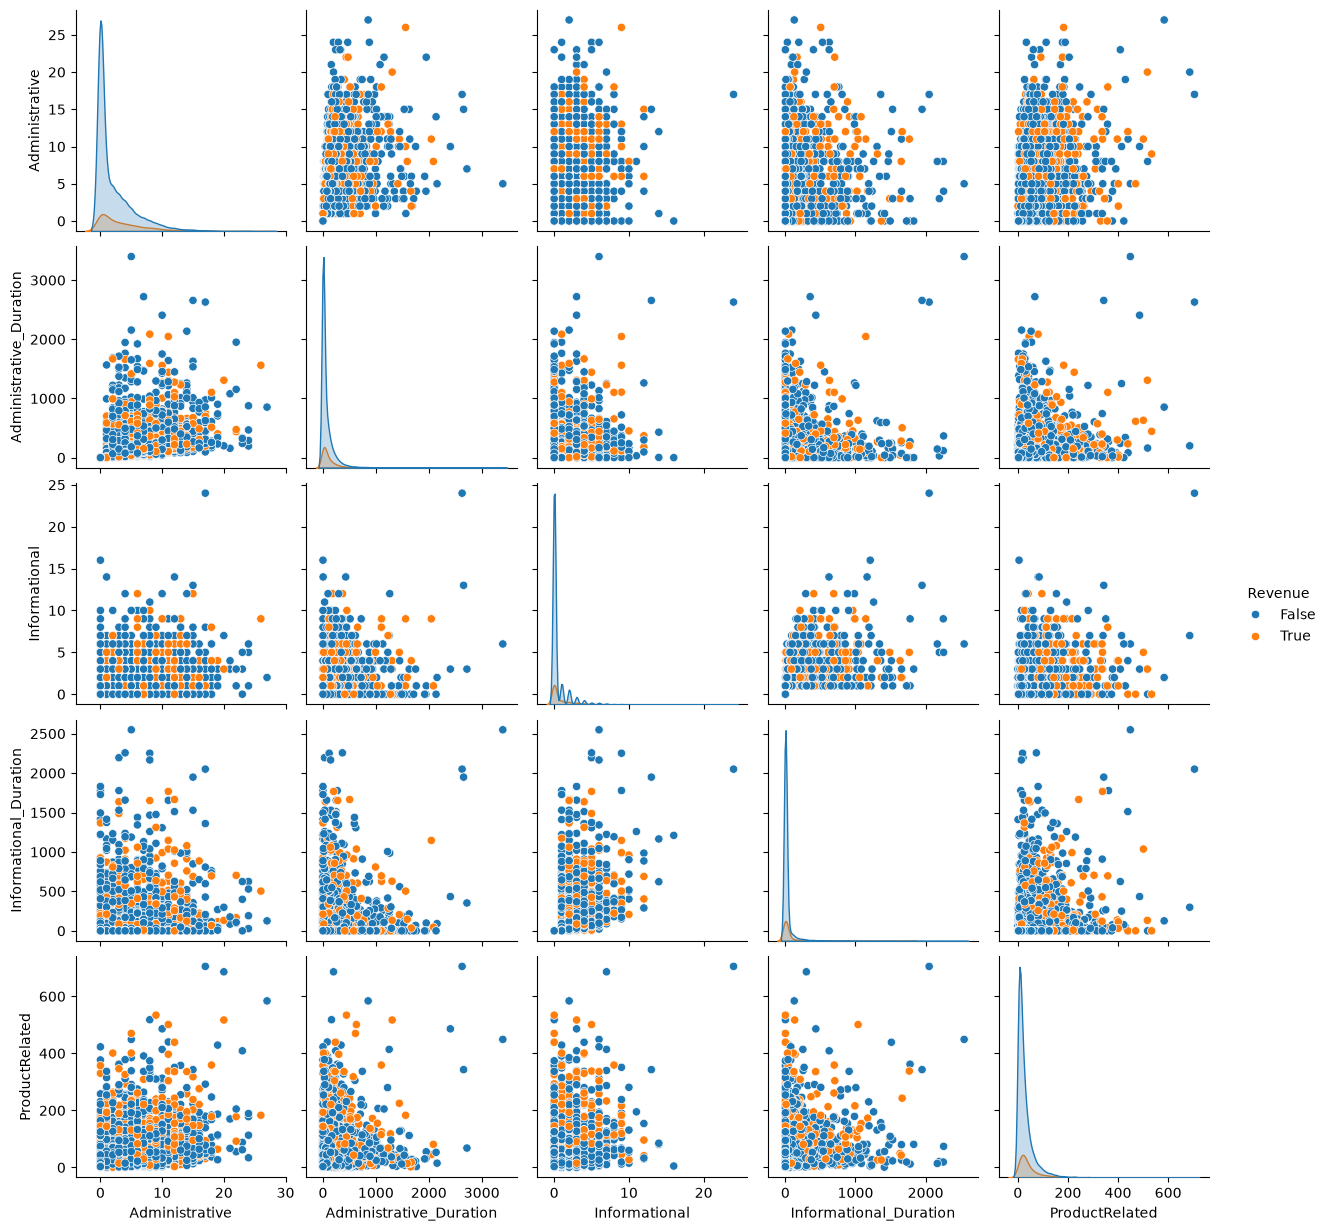

In [ ]:
# Pairplot on the first five numerical features, plus one-hot encoding of
# Month and VisitorType to compute a complete correlation matrix (including the categorical features)
cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
n = 0
sns.pairplot(df[cols[n:n+5] + ['Revenue']], hue = 'Revenue')
# One hot encoding of month and visitor type
X_new = pd.get_dummies(X, columns=['Month', 'VisitorType'], drop_first=True)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,...,-0.056863,0.020034,0.015072,-0.114672,-0.072220,0.182339,0.008907,0.005997,-0.036083,0.128738
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,...,-0.046550,0.002276,0.001506,-0.085491,-0.068133,0.166951,-0.008773,0.005950,-0.027183,0.120489
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,...,0.063030,0.009766,0.041178,-0.004090,0.059062,-0.034281,-0.046044,-0.040081,0.028112,0.129908
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,...,0.078709,0.008852,0.048276,0.013439,0.072815,-0.056810,-0.062465,-0.050956,0.034763,0.171987


Average squared correlation for features exceeding 0.7 somewhere:
ProductRelated             0.093792
ProductRelated_Duration    0.093848
BounceRates                0.079232
ExitRates                  0.087275
dtype: float64


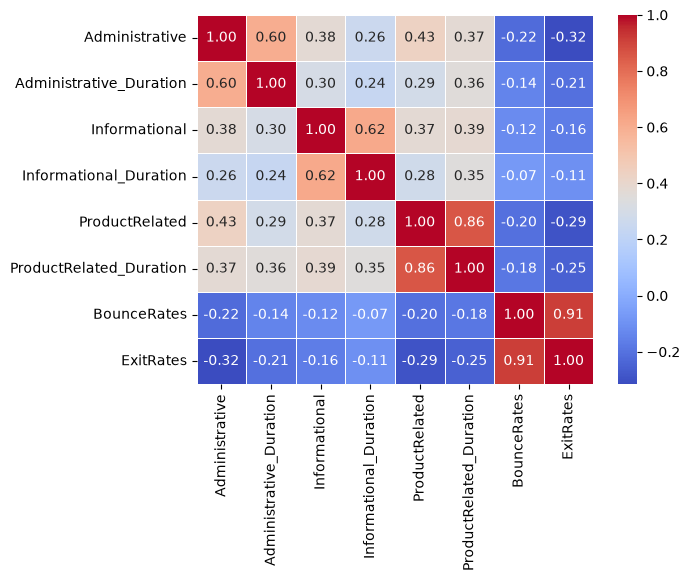

In [ ]:
# Plotting correlation matrix for corr > 0.5
X_corr = X_new.corr()
# Pick only correlated features andm ake plot of them, drop the rest from plotting drop diagonal
corr_features = X_corr[(abs(X_corr) > 0.5) & (X_corr < 1)].dropna(how='all').dropna(axis=1, how='all')
corr_columns = corr_features.columns

sns.heatmap(X_corr.loc[corr_columns, corr_columns], annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# Compute a single global average of squared correlations > 0.7
mask_high = (abs(X_corr) > 0.7) & (X_corr < 1.0)
features_exceeding = mask_high.any(axis=1)  # True for rows that have at least one high correlation

filtered_subset = X_corr.loc[features_exceeding]
display(filtered_subset)
avg_squared_corr_flagged = filtered_subset.pow(2).mean(axis=1)

print("Average squared correlation for features exceeding 0.7 somewhere:")
print(avg_squared_corr_flagged)

# Plot all correlations so it is big and readable
# fig, ax = plt.subplots(figsize=(12, 10))
# sns.heatmap(X_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)


The correlation matrix highlights two key pieces of information regarding the correlation between features:

*   ExitRates and BounceRates have a correlation coefficient of 0.91
*   ProductRelated and ProductRelated_Duration have a correlation coefficient of 0.86.

These values allow us to identify the interdependence of the features, analyzed based on their meanings:


*   **BounceRates:** Average bounce rate of the pages visited by the visitor (the frequency with which pages were closed without any interaction).
*   **ExitRates:** Average exit rate of the pages visited by the visitor (frequency of pages closed).

From this view of the domain, we can conclude that the number of pages closed without interaction (bounce rates) is directly dependent on the number of pages closed (exit rates).

Since bounce rates are a subset of exit rates, let's consider empirically excluding the more specific category (bounce rates).

### Boxplot after split
Visualise the distribution of the three duration features on the training set.

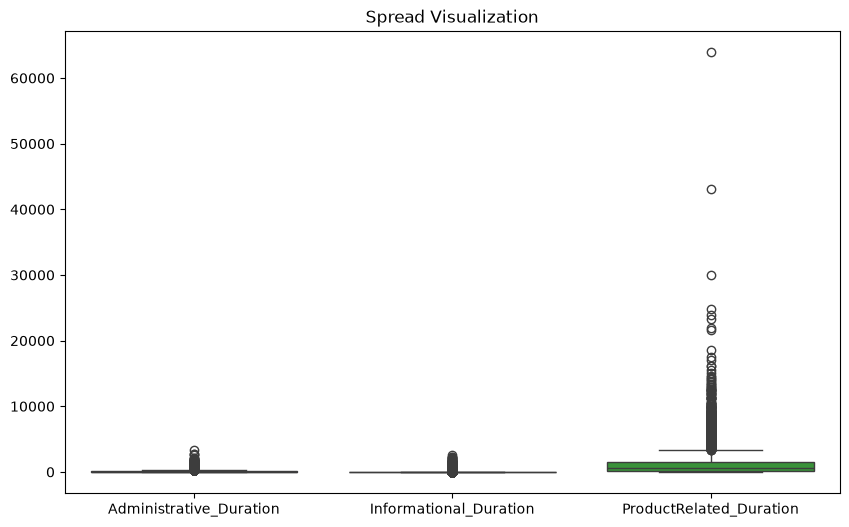

3398.75


In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data = X_train[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']])
plt.title("Spread Visualization")
plt.show()
print(X_train['Administrative_Duration'].max())

### Preprocessing pipeline
`ColumnTransformer` with:
- **One-Hot Encoding** for categorical features (`Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`).
- **Min-Max scaling** for the numerical ones.

`remainder='drop'` ensures no unexpected column sneaks in. The preprocessor is fit only on the training set to avoid data leakage.


In [ ]:
# ColumnTransformer: One-Hot for categorical, Min-Max for numerical
# sparse_threshold=0 keeps the output dense (73 features, dense is fine)
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
import numpy as np


categorical_values = ['Month','VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
numerical_values = ['PageValues', 'ExitRates']
# Exclude BounceRates
numerical_values = X.columns.difference(categorical_values + ['BounceRates']).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('onenc', OneHotEncoder(handle_unknown='ignore'), categorical_values),
        ('minmax', MinMaxScaler(), numerical_values)
    ],
    remainder='drop',
    sparse_threshold=0
)

# Fit on the training set, then transform the test set with the same
# pipeline. Fitting on train only avoids data leakage
X_train_transf = preprocessor.fit_transform(X_train, y_train)

denseXTrain = X_train_transf
dfTransformed = pd.DataFrame(denseXTrain, columns = preprocessor.get_feature_names_out())
dfTransformed.head()

print(X_train_transf.shape)


(9864, 73)


In [ ]:
X_test_transf = preprocessor.transform(X_test)
print("X_train_transf:", X_train_transf.shape, "| X_test_transf:", X_test_transf.shape)

X_train_transf: (9864, 73) | X_test_transf: (2466, 73)


Average squared correlation for features exceeding 0.7 somewhere:
onenc__VisitorType_New_Visitor          0.030480
onenc__VisitorType_Other                0.030960
onenc__VisitorType_Returning_Visitor    0.031832
onenc__OperatingSystems_1               0.034919
onenc__OperatingSystems_8               0.032270
onenc__Browser_1                        0.036046
onenc__Browser_13                       0.035956
minmax__ProductRelated                  0.034066
minmax__ProductRelated_Duration         0.034043
dtype: float64


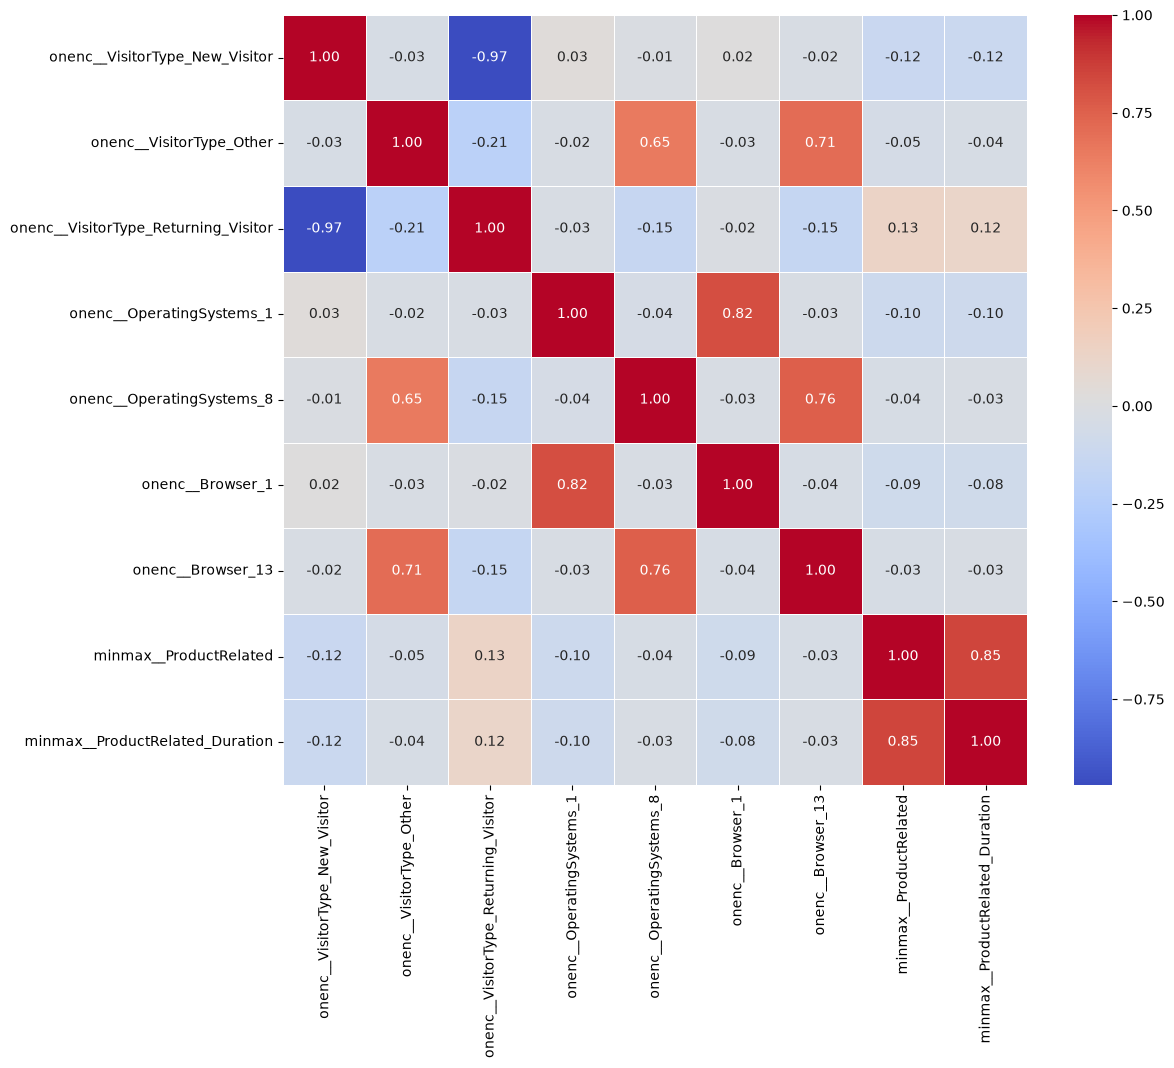

In [ ]:
# Plotting correlation matrix for corr > 0.5
X_corr = dfTransformed.corr()
# Pick only correlated features andm ake plot of them, drop the rest from plotting drop diagonal
corr_features = X_corr[(abs(X_corr) > 0.7) & (X_corr < 1)].dropna(how='all').dropna(axis=1, how='all')
corr_columns = corr_features.columns

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(X_corr.loc[corr_columns, corr_columns], annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# Compute a single global average of squared correlations > 0.7
mask_high = (abs(X_corr) > 0.7) & (X_corr < 1.0)
features_exceeding = mask_high.any(axis=1)  # True for rows that have at least one high correlation

filtered_subset = X_corr.loc[features_exceeding]
# display(filtered_subset)
avg_squared_corr_flagged = filtered_subset.pow(2).mean(axis=1)

print("Average squared correlation for features exceeding 0.7 somewhere:")
print(avg_squared_corr_flagged)

# Plot all correlations so it is big and readable
# sns.heatmap(X_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)


## Phase 3 — Trivial benchmark

### Benchmark: always predict "No purchase"
A trivial classifier that predicts the majority class reaches 84.5% accuracy but **zero F1** on the positive class. Any meaningful model must beat this on F1, recall, or AUC — not just on accuracy.

In [ ]:
# Benchmark: always predict "No purchase". Accuracy ~84.5%, F1 = 0
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_dummy = [False] * len(y_test)
print(f"Acc={accuracy_score(y_test, y_pred_dummy):.3f}  "
      f"Prec={precision_score(y_test, y_pred_dummy, zero_division=0):.3f}  "
      f"Rec={recall_score(y_test, y_pred_dummy, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, y_pred_dummy, zero_division=0):.3f}")

Acc=0.845  Prec=0.000  Rec=0.000  F1=0.000


## Phase 4 — Models, cross-validation, hyperparameter tuning

### Model pool
Six classifiers with different inductive biases:
- **Logistic Regression** — linear baseline, interpretable.
- **Decision Tree** — single tree, reference for the ensembles.
- **Random Forest** — bagged trees, robust and non-linear.
- **HistGB** — boosted trees, strong on tabular data.
- **SVM (RBF)** — kernel method, good in high-dimensional spaces.
- **KNN** — distance-based baseline; no `class_weight` support, so it is identical in the two settings.

Each model is tested twice:
- **`raw`**: no class reweighting.
- **`balanced`**: `class_weight='balanced'` to compensate for the 84.5%/15.5% imbalance.

In [ ]:
# Return the same six classifiers with or without class_weight='balanced'
# KNN does not support class_weight, so it is identical in the two settings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn import svm

def make_models(balanced: bool):
    cw = 'balanced' if balanced else None
    return {
        'logreg':  LogisticRegression(class_weight=cw, max_iter=1000, random_state=42),
        'tree':    DecisionTreeClassifier(class_weight=cw, random_state=42),
        'randfor': RandomForestClassifier(class_weight=cw, random_state=42),
        'HistGB':  HistGradientBoostingClassifier(class_weight=cw, random_state=42),
        'svc':     svm.SVC(class_weight=cw, random_state=42),
        'knn':     KNeighborsClassifier(),  # KNN non supporta class_weight: resta identico nei due esperimenti
    }
# for el in models:
#   models[el].fit(X_train_transf, y_train)
#   print(f'Confidence score of {el}:', models[el].score(X_train_transf, y_train))

### Baseline CV (raw vs balanced)
5-fold stratified cross-validation of each model in the two settings. This gives a first comparison before hyperparameter tuning.

In [ ]:
# 5-fold stratified CV with shuffle, scoring f1 / precision / recall
# We evaluate each model twice: raw and balanced
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['f1', 'precision', 'recall']

baseline_rows = []
for setting_name, is_balanced in [('raw', False), ('balanced', True)]:
    for model_name, clf in make_models(is_balanced).items():
        pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
        res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)
        baseline_rows.append({
            'Setting': setting_name, 'Model': model_name,
            'F1': res['test_f1'].mean(),
            'Precision': res['test_precision'].mean(),
            'Recall': res['test_recall'].mean(),
        })

df_baseline_all = pd.DataFrame(baseline_rows).sort_values(['Setting', 'F1'], ascending=[True, False])
display(df_baseline_all)

,Setting,Model,F1,Precision,Recall
8,balanced,randfor,0.680152,0.636173,0.731981
9,balanced,HistGB,0.670002,0.585365,0.784402
7,balanced,tree,0.555130,0.554863,0.556368
6,balanced,logreg,0.554791,0.436078,0.763418
10,balanced,svc,0.465578,0.351473,0.691313
11,balanced,knn,0.231984,0.484054,0.152686
3,raw,HistGB,0.654912,0.712704,0.606161
2,raw,randfor,0.611775,0.750485,0.516368
1,raw,tree,0.576410,0.570388,0.583844
0,raw,logreg,0.414353,0.770454,0.283748


### Tuning helpers
`run_grid_search` wraps `GridSearchCV` (5-fold, scoring = macro-F1) and returns the best estimator plus a tidy table of results. `tune_models` applies it to every model in the pool, in both settings.

In [ ]:
# Helper functions: run GridSearchCV with a pipeline (preproc + classifier)
# and return both the best estimator and a compact table of results
from sklearn.model_selection import GridSearchCV

def run_grid_search(estimator, param_grid: dict, X_train, y_train, cv=5, train_score=True):
    """Run GridSearchCV and return the fitted search plus a compact results table."""

    search = GridSearchCV(estimator, param_grid, cv=cv, scoring='f1_macro', return_train_score=train_score)
    search.fit(X_train, y_train)

    # Get standard cv_results_
    results = search.cv_results_

    # Build a clean DataFrame that unpacks the params dictionary into separate columns
    df_res = pd.DataFrame(results['params'])
    df_res['mean_test_f1_score'] = results['mean_test_score']
    df_res['std_test_f1_score'] = results['std_test_score']

    if train_score:
        df_res['mean_train_f1_score'] = results['mean_train_score']

    df_res = df_res.sort_values('mean_test_f1_score', ascending=False)
    return search, df_res


def tune_models(models, param_grids, X_train, y_train, cv=5, train_score=True):
    """Run grid search for each model and return a dictionary of fitted searches and results tables."""
    search_results = {}
    for model_name, model in models.items():
        print(f"Tuning {model_name}...")

        pipe = Pipeline([
            ('preproc', preprocessor),
            ('clf', model)
        ])

        original_grid = param_grids.get(model_name, {})
        param_grid = {f'clf__{key}': value for key, value in original_grid.items()}

        search, cv_results = run_grid_search(pipe, param_grid, X_train, y_train, cv=cv, train_score=train_score)

        print(f"Best params {model_name}: {search.best_params_}")
        print(f"Best CV macro-F1 {model_name}: {search.best_score_:.3f}")
        print()

        search_results[model_name] = (search, cv_results)
    return search_results


### KNN — separate grid search
We tune KNN on the preprocessed training set directly (`X_train_transf`), since it does not use the full pipeline (no class_weight to set).

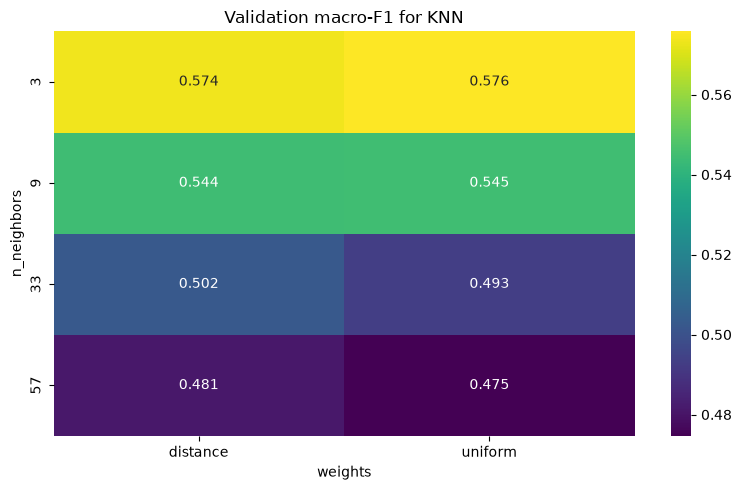

Best params: {'n_neighbors': 3, 'weights': 'uniform'}
Best CV macro-F1: 0.5758168158899553


,n_neighbors,weights,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
0,3,uniform,0.575817,0.015979,0.751829
1,3,distance,0.573504,0.013839,1.000000
2,9,uniform,0.544775,0.018158,0.594785
3,9,distance,0.544464,0.009923,1.000000
5,33,distance,0.502447,0.005754,1.000000


In [ ]:
## KNN
from sklearn.neighbors import KNeighborsClassifier


knn_param_grid = {
    "n_neighbors": [3, 9, 33, 57],
    "weights": ["uniform", "distance"],
}

search, cv_results = run_grid_search(
    KNeighborsClassifier(),
    knn_param_grid,
    X_train_transf,
    y_train,
    cv=5,
)


pivot = cv_results.pivot(index="n_neighbors", columns="weights", values="mean_test_f1_score")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Validation macro-F1 for KNN")
plt.tight_layout()
plt.show()

print("Best params:", search.best_params_)
print("Best CV macro-F1:", search.best_score_)
cv_results.head()

### RBF SVM — separate grid search
Same as above for the RBF kernel SVM. The heatmap shows the validation macro-F1 as a function of `C` and `gamma`.

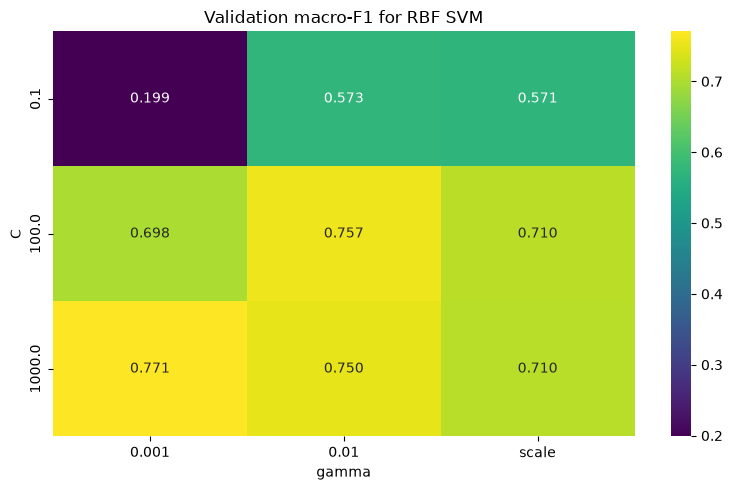

Best params: {'C': 1000, 'gamma': 0.001}
Best CV macro-F1: 0.7705809979592869


,C,gamma,mean_test_f1_score,std_test_f1_score
6,1000.0,0.001,0.770581,0.014882
4,100.0,0.01,0.756583,0.008080
7,1000.0,0.01,0.749533,0.007179
5,100.0,scale,0.710310,0.012880
8,1000.0,scale,0.709629,0.004008


In [ ]:
## RBF SVM
svm_param_grid = {
    "C": [0.1, 100, 1000],
    "gamma": [0.001, 0.01, "scale"],
}


search, cv_results = run_grid_search(
    svm.SVC(kernel="rbf", class_weight="balanced"),
    svm_param_grid,
    X_train_transf,
    y_train,
    cv=5,
    train_score=False,
)

pivot = cv_results.pivot(index="C", columns="gamma", values="mean_test_f1_score")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Validation macro-F1 for RBF SVM")
plt.tight_layout()
plt.show()

print("Best params:", search.best_params_)
print("Best CV macro-F1:", search.best_score_)
cv_results.head()

### Full hyperparameter tuning (raw + balanced)
Run `tune_models` on every classifier in both settings. The tuning time is measured and printed, to document the computational cost.

In [ ]:
import time
param_grids = {
    'logreg': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga']
    },
    'randfor': {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 5, 10],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'tree' : {
        'max_depth': [5, 10, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'HistGB' : {
        'max_leaf_nodes': [15, 31, 63],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_iter' : [100, 200, 500]
    },
    'svc': {
        "C": [0.1, 100, 1000],
        "gamma": [0.001, 0.01, "auto"],
        "kernel": ["rbf"],
    },
    'knn': {
        "n_neighbors": [3, 9, 15, 33],
        "weights": ["uniform", "distance"],
    },
}


all_search_results = {}

# Run the full tuning for both settings and measure the elapsed time
for setting_name, is_balanced in [('raw', False), ('balanced', True)]:
    print(f"\n{'='*20} Setting: {setting_name} {'='*20}")
    models = make_models(is_balanced)
    start = time.time()
    all_search_results[setting_name] = tune_models(models, param_grids, X_train, y_train, cv=5, train_score=True)
    print(f"Tempo tuning ({setting_name}): {(time.time()-start)/60:.1f} min")


# for setting_name, search_results in all_search_results.items():
#     print(f"\n{'='*20} Setting: {setting_name} {'='*20}")
#     for model_name, (search, df_res) in search_results.items():
#         print(f"\n--- Top Results for {setting_name} / {model_name} ---")
#         display(df_res.head(3))


==================== Setting: raw ====================
Tuning logreg...
Best params logreg: {'clf__C': 10, 'clf__solver': 'saga'}
Best CV macro-F1 logreg: 0.720

Tuning tree...
Best params tree: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Best CV macro-F1 tree: 0.801

Tuning randfor...
Best params randfor: {'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV macro-F1 randfor: 0.762

Tuning HistGB...
Best params HistGB: {'clf__learning_rate': 0.01, 'clf__max_iter': 500, 'clf__max_leaf_nodes': 15}
Best CV macro-F1 HistGB: 0.806

Tuning svc...
Best params svc: {'clf__C': 1000, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Best CV macro-F1 svc: 0.731

Tuning knn...
Best params knn: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
Best CV macro-F1 knn: 0.577

Tempo tuning (raw): 6.8 min

==================== Setting: balanced ====================
Tuning logreg...
Best params logreg: {'clf__C': 10,

In [ ]:
raw_search = all_search_results['raw']
balanced_search = all_search_results['balanced']
print('==========RAW results============')
for model_name, (search, df_res) in raw_search.items() :
    print(f"\n--- Top Results for {model_name} ---")
    display(df_res.head(3))

print('=========Balanced results=========')
for model_name, (search, df_res) in balanced_search.items() :
    print(f"\n--- Top Results for {model_name} ---")
    display(df_res.head(3))

==========RAW results============

--- Top Results for logreg ---


,clf__C,clf__solver,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
7,10.0,saga,0.719870,0.016539,0.722129
6,10.0,lbfgs,0.719490,0.016955,0.722313
5,1.0,saga,0.673733,0.014442,0.679421



--- Top Results for tree ---


,clf__max_depth,clf__min_samples_leaf,clf__min_samples_split,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
0,5,1,5,0.801109,0.012276,0.825884
2,5,2,5,0.801109,0.012276,0.825591
5,5,4,10,0.801072,0.012069,0.825292



--- Top Results for randfor ---


...

,clf__learning_rate,clf__max_iter,clf__max_leaf_nodes,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
14,0.1,200,63,0.800360,0.008895,0.999468
20,0.2,100,63,0.800184,0.009210,0.999274
13,0.1,200,31,0.799747,0.009997,0.954650



--- Top Results for svc ---


,clf__C,clf__gamma,clf__kernel,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
6,1000.0,0.001,rbf,0.770657,0.013482,0.785076
4,100.0,0.01,rbf,0.758466,0.009063,0.792032
5,100.0,auto,rbf,0.756053,0.008862,0.798294



--- Top Results for knn ---


,clf__n_neighbors,clf__weights,mean_test_f1_score,std_test_f1_score,mean_train_f1_score
0,3,uniform,0.577461,0.017464,0.753462
1,3,distance,0.575405,0.013626,1.000000
2,9,uniform,0.546939,0.018227,0.596562


========== RAW ==========

→ Heatmap for logreg


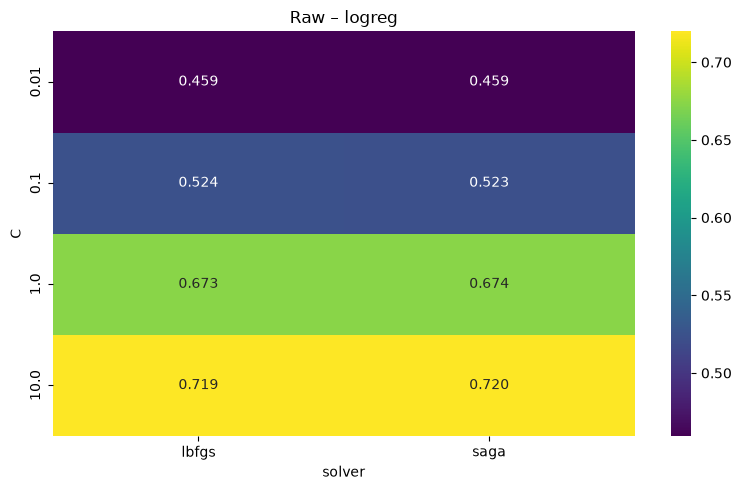


→ Heatmap for knn


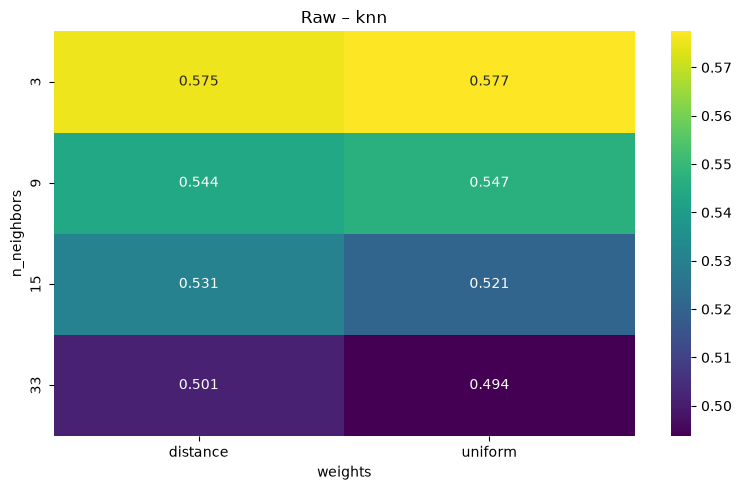

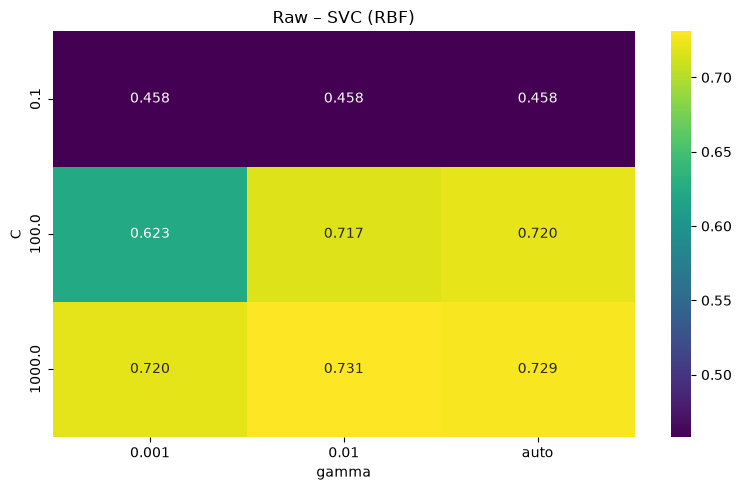


========== BALANCED ==========

→ Heatmap for logreg


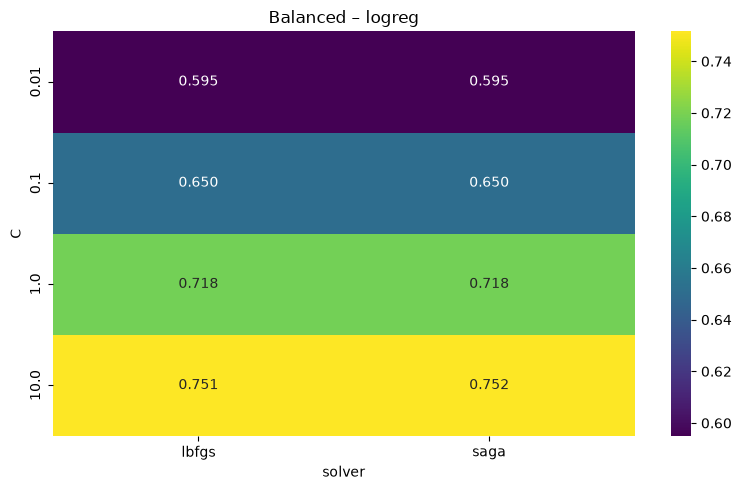


→ Heatmap for knn


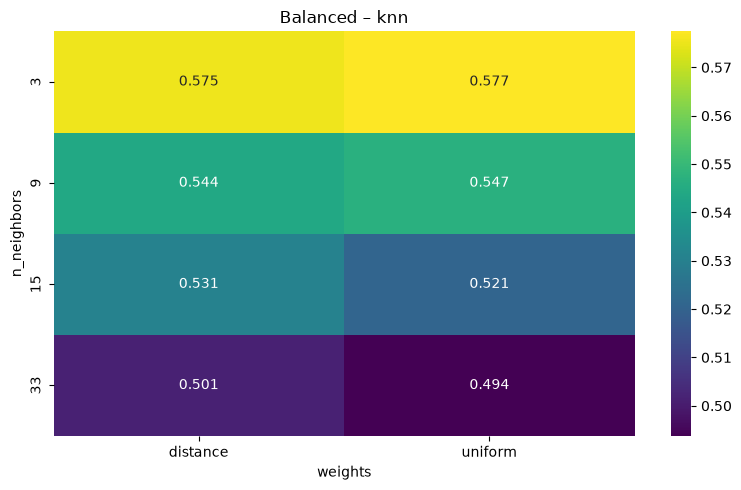

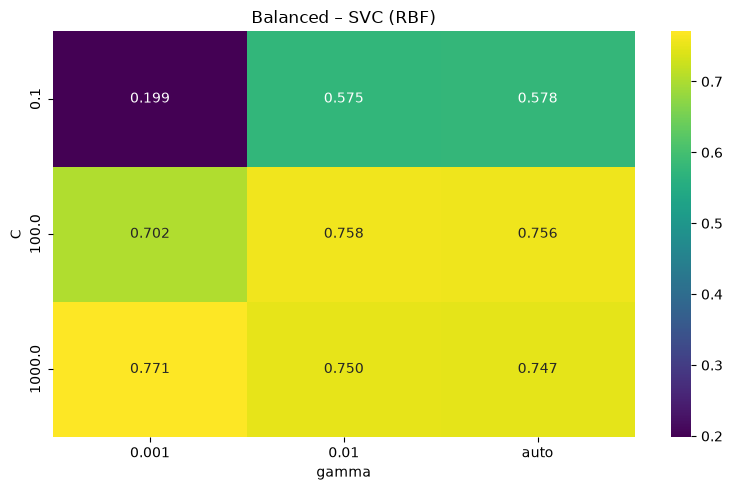

In [ ]:
def plot_param_heatmap(df_res, param1: str, param2: str, title: str = None):
    """
    Create a heatmap of mean_test_f1_score for two hyperparameters.
    """
    # Clean parameter names (remove 'clf__' prefix if present)
    p1 = param1.replace('clf__', '')
    p2 = param2.replace('clf__', '')

    pivot = df_res.pivot_table(
        index=param1,
        columns=param2,
        values='mean_test_f1_score',
        aggfunc='mean'          # in case of duplicates
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(title or f"Validation macro-F1\n{p1} vs {p2}")
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    plt.tight_layout()
    plt.show()

def plot_all_possible_heatmaps(search_dict, title_prefix=""):
    for model_name, (search, df_res) in search_dict.items():
        # Get the hyperparameter columns (exclude score columns)
        param_cols = [c for c in df_res.columns if c.startswith('clf__')]

        if len(param_cols) == 2:
            print(f"\n→ Heatmap for {model_name}")
            plot_param_heatmap(
                df_res,
                param1=param_cols[0],
                param2=param_cols[1],
                title=f"{title_prefix}{model_name}"
            )


# Usage
print("========== RAW ==========")
plot_all_possible_heatmaps(raw_search, title_prefix="Raw – ")

search, df_res = raw_search['svc']

plot_param_heatmap(
    df_res,
    param1='clf__C',
    param2='clf__gamma',
    title="Raw – SVC (RBF)"
)

print("\n========== BALANCED ==========")
plot_all_possible_heatmaps(balanced_search, title_prefix="Balanced – ")

# For the SVM in raw_search
search, df_res = balanced_search['svc']

plot_param_heatmap(
    df_res,
    param1='clf__C',
    param2='clf__gamma',
    title="Balanced – SVC (RBF)"
)

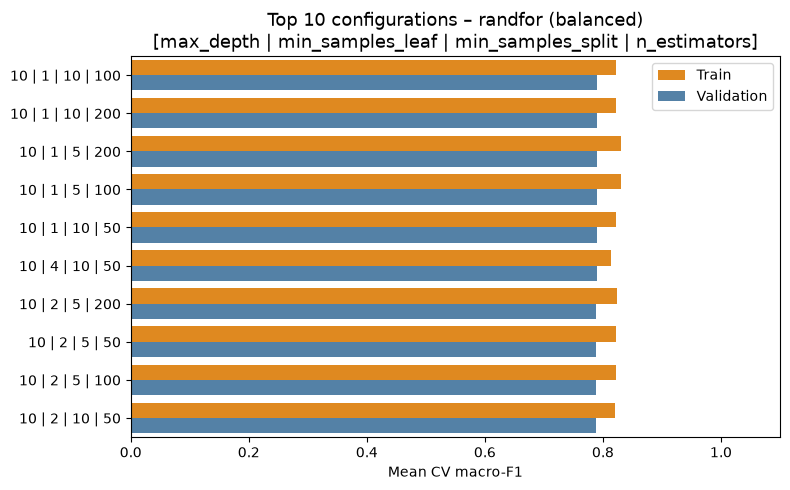

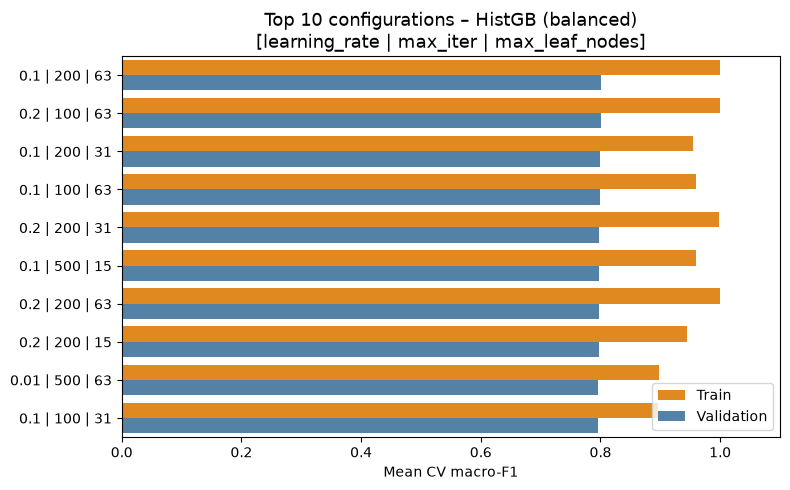

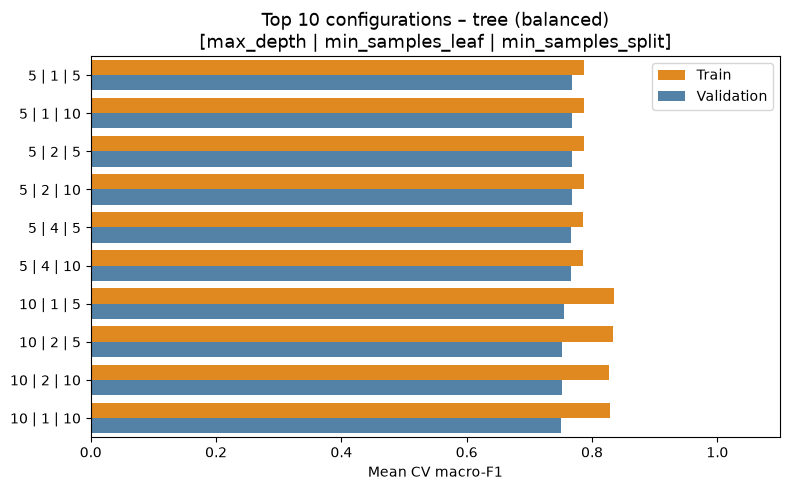

In [ ]:
def plot_top_configs(df_res, model_name, top_n=10):
    plot_df = df_res.head(top_n).copy()

    param_cols = [c for c in plot_df.columns if c.startswith('clf__')]
    short_names = [c.replace('clf__', '') for c in param_cols]
    plot_df['config'] = plot_df[param_cols].astype(str).agg(' | '.join, axis=1)


    plot_df_melted = plot_df.melt(
        id_vars='config',
        value_vars=['mean_train_f1_score', 'mean_test_f1_score'],
        var_name='Score Type',
        value_name='F1 Score'
    )
    plot_df_melted['Score Type'] = plot_df_melted['Score Type'].map({
        'mean_train_f1_score': 'Train',
        'mean_test_f1_score': 'Validation',
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=plot_df_melted,
        x='F1 Score',
        y='config',
        hue='Score Type',
        palette={'Train': 'darkorange', 'Validation': 'steelblue'},
        ax=ax
    )

    param_header = " | ".join(short_names)
    ax.set_title(f"Top {top_n} configurations – {model_name}\n[{param_header}]", fontsize=13)

    # ax.set_title(f'The Importance of max_depth Parameter for Random Forest\n[{param_header}]', fontsize=13)

    ax.set_xlabel("Mean CV macro-F1")
    ax.set_ylabel("")
    ax.set_xlim(0,1.1)
    ax.legend(title="")

    plt.tight_layout()
    plt.show()

_, df_res = balanced_search['randfor']
plot_top_configs(df_res, model_name='randfor (balanced)', top_n=10)

_, df_res = balanced_search['HistGB']
plot_top_configs(df_res, model_name='HistGB (balanced)', top_n=10)

_, df_res = balanced_search['tree']
plot_top_configs(df_res, model_name='tree (balanced)', top_n=10)


### Final evaluation on the test set
For each model and setting, fit the best configuration on the full training set, predict on the test set, and store accuracy, precision, recall, F1 and AUC.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt
import pandas as pd

best_models = {}
final_rows = []

for setting_name, search_results in all_search_results.items():
    best_models[setting_name] = {}
    for name, (search, cv_results) in search_results.items():
        model = search.best_estimator_
        best_models[setting_name][name] = model

        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        positive_label = '1' if '1' in report else 'True' if 'True' in report else list(report.keys())[0]
        y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

        final_rows.append({
            'Setting': setting_name, 'Model': name,
            'Accuracy': report['accuracy'],
            'Precision': report[positive_label]['precision'],
            'Recall': report[positive_label]['recall'],
            'F1': report[positive_label]['f1-score'],
            'AUC': roc_auc_score(y_test, y_score),
            'CV_F1': search.best_score_,
        })

df_final_all = pd.DataFrame(final_rows).sort_values(['Setting', 'F1'], ascending=[True, False])
display(df_final_all)

,Setting,Model,Accuracy,Precision,Recall,F1,AUC,CV_F1
9,balanced,HistGB,0.884834,0.616114,0.680628,0.646766,0.915444,0.800360
8,balanced,randfor,0.856853,0.524126,0.824607,0.640895,0.914542,0.790097
10,balanced,svc,0.860908,0.537864,0.725131,0.617614,0.895264,0.770657
7,balanced,tree,0.834955,0.481481,0.850785,0.614948,0.906292,0.768161
6,balanced,logreg,0.832522,0.473862,0.735602,0.576410,0.887977,0.751585
11,balanced,knn,0.828467,0.391534,0.193717,0.259194,0.648871,0.577461
3,raw,HistGB,0.902271,0.718266,0.607330,0.658156,0.931689,0.805947
1,raw,tree,0.890916,0.655647,0.623037,0.638926,0.915498,0.801109
2,raw,randfor,0.894566,0.821053,0.408377,0.545455,0.916419,0.762341
4,raw,svc,0.883212,0.739796,0.379581,0.501730,0.856129,0.730975


### ROC and Precision-Recall curves
Both curves for the two best models (`HistGB`, `randfor`) in the balanced setting. ROC is threshold-independent; PR is more informative when the positive class is rare.

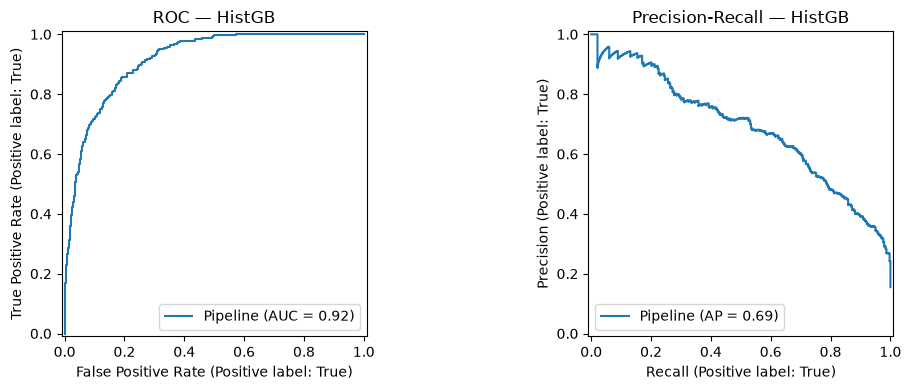

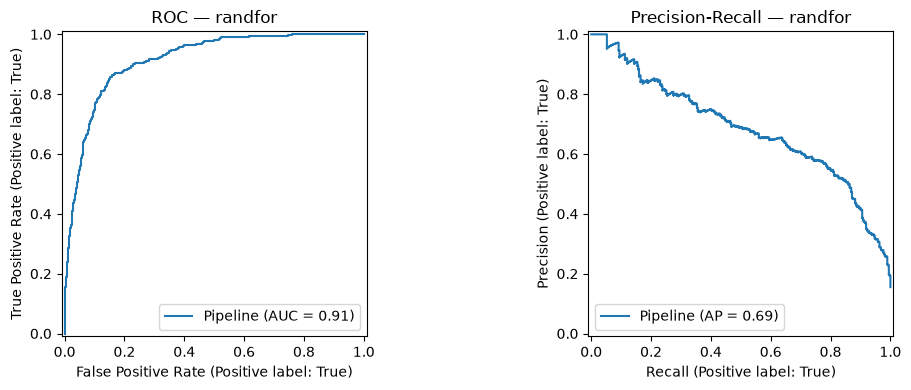

In [ ]:
# ROC and Precision-Recall curves for HistGB and randfor in the balanced setting
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
SETTING_FOR_PLOTS = 'balanced'

for name in ['HistGB', 'randfor']:
    model = best_models[SETTING_FOR_PLOTS][name]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    axes[0].set_title(f'ROC — {name}')
    axes[1].set_title(f'Precision-Recall — {name}')
    plt.tight_layout()
    plt.show()

### Permutation importance (scoring = F1)
Feature importance on the test set. It measures how much F1 drops when each feature is randomly permuted, which is more reliable than impurity-based importance.

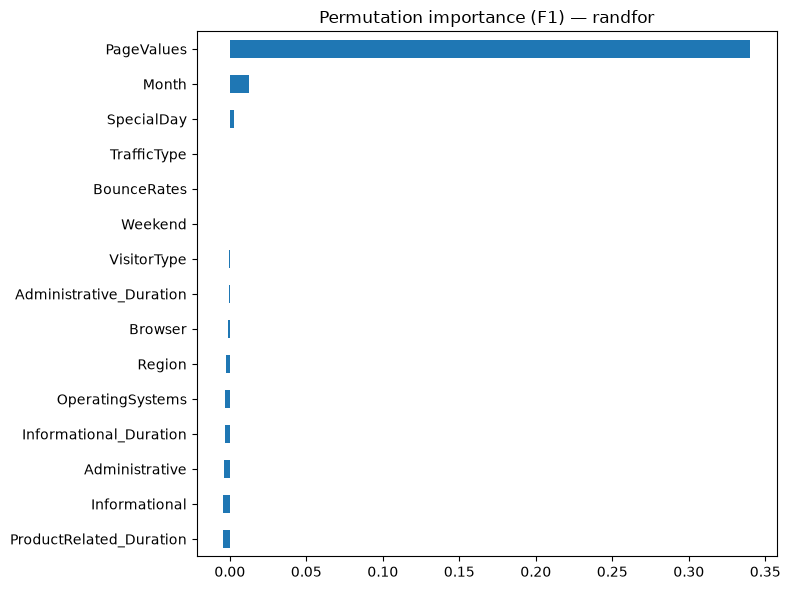

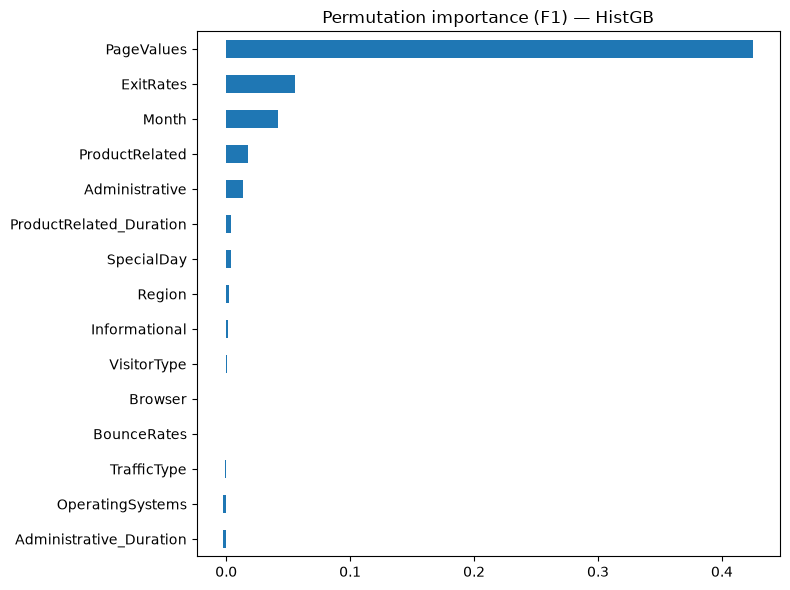

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

for name in ['randfor', 'HistGB']:
    model = best_models['balanced'][name]
    r = permutation_importance(model, X_test, y_test, n_repeats=5,
                               random_state=42, scoring='f1')
    imp = pd.Series(r.importances_mean, index=X_test.columns)\
            .sort_values(ascending=False).head(15)
    imp.plot(kind='barh', figsize=(8, 6),
             title=f'Permutation importance (F1) — {name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Confusion matrices — raw vs balanced
All six classifiers in both settings. Rows are true labels, columns are predictions.

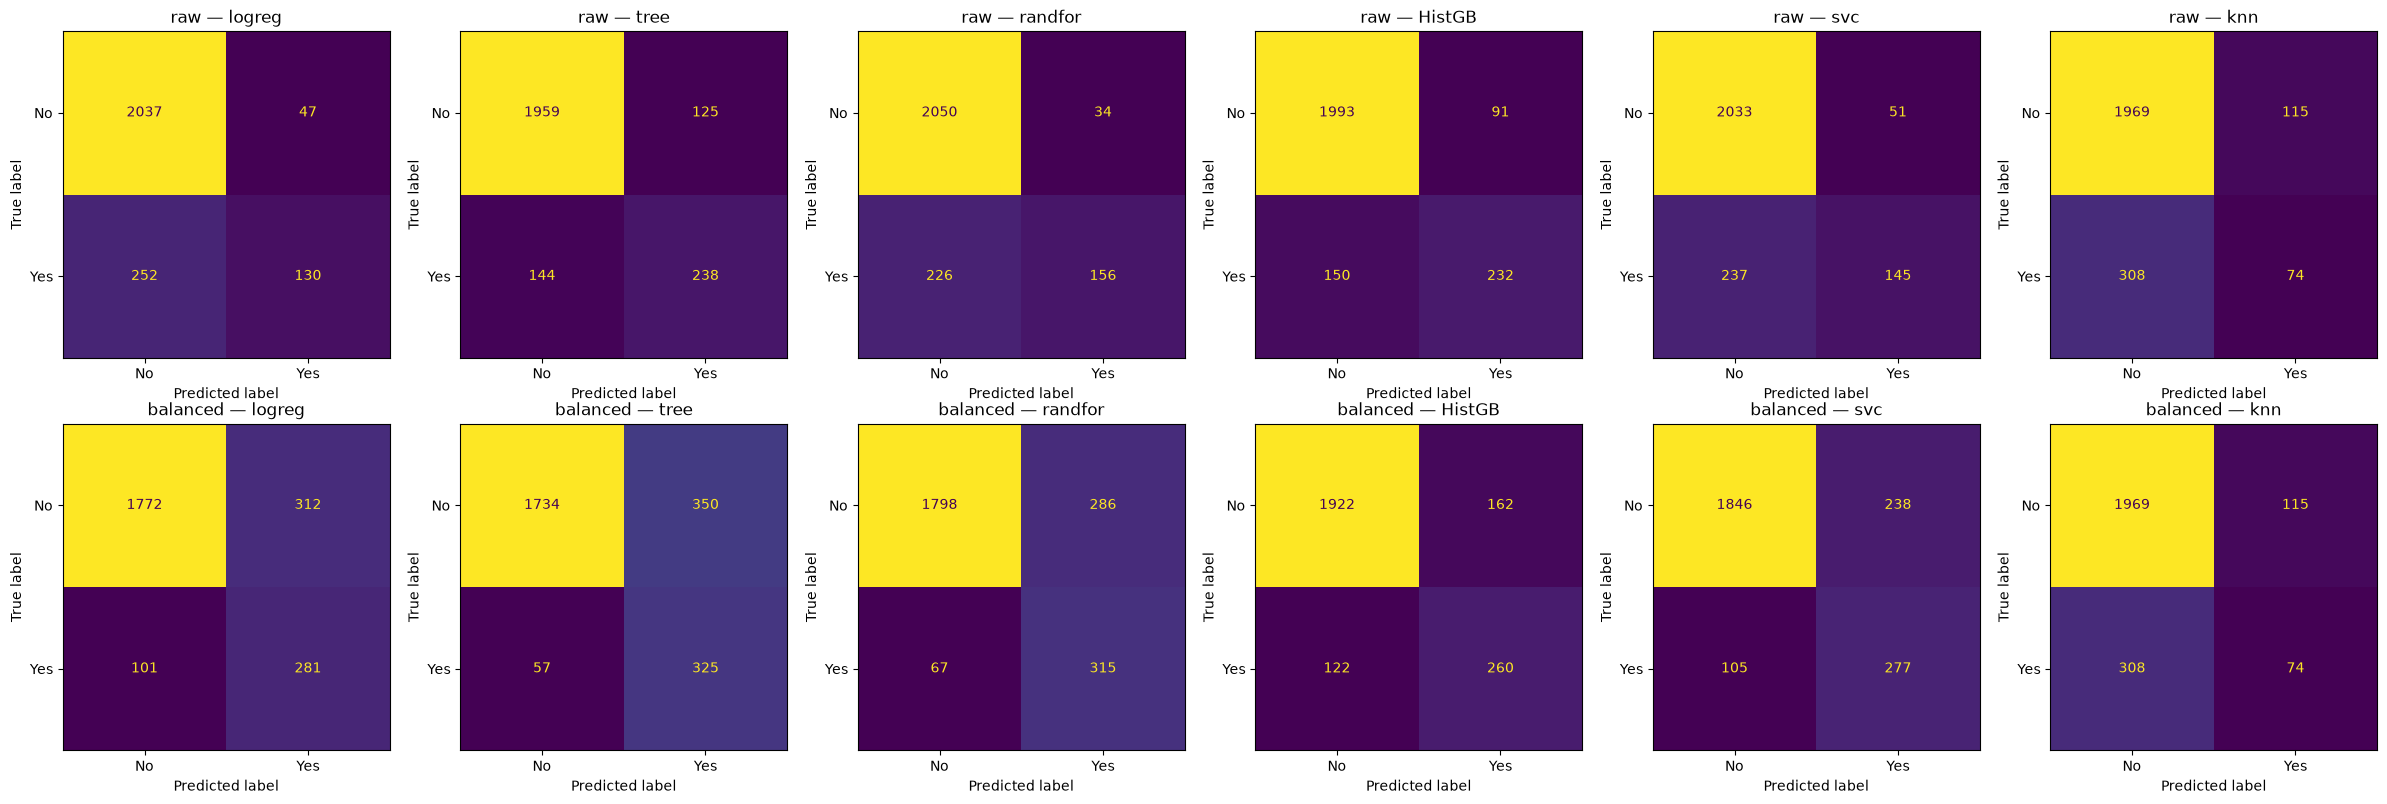

In [ ]:
# 2x6 grid: top row = raw, bottom row = balanced, one panel per model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrices for both settings
n_models = 6
fig, axes = plt.subplots(2, n_models, figsize=(4 * n_models, 8))

for row_idx, setting_name in enumerate(['raw', 'balanced']):
    for col_idx, (name, model) in enumerate(best_models[setting_name].items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(
            ax=axes[row_idx, col_idx], colorbar=False
        )
        axes[row_idx, col_idx].set_title(f'{setting_name} — {name}')

plt.tight_layout()
plt.show()

### Final results table
Combine the trivial benchmark with the test-set results in both settings, sorted by F1. This is the summary table used in the report.

In [ ]:
# Add the trivial benchmark to the results table and sort by F1
import pandas as pd
baseline = pd.DataFrame([{'Setting': 'benchmark', 'Model': 'Always-False',
                          'Accuracy': 0.8453, 'Precision': 0.0, 'Recall': 0.0,
                          'F1': 0.0, 'AUC': 0.5, 'CV_F1': None}])

df_report_final = pd.concat([baseline, df_final_all], ignore_index=True)
df_report_final = df_report_final.sort_values(['Setting','F1'], ascending=[True, False])
display(df_report_final)

,Setting,Model,Accuracy,Precision,Recall,F1,AUC,CV_F1
1,balanced,HistGB,0.884834,0.616114,0.680628,0.646766,0.915444,0.80036
2,balanced,randfor,0.856853,0.524126,0.824607,0.640895,0.914542,0.790097
3,balanced,svc,0.860908,0.537864,0.725131,0.617614,0.895264,0.770657
4,balanced,tree,0.834955,0.481481,0.850785,0.614948,0.906292,0.768161
5,balanced,logreg,0.832522,0.473862,0.735602,0.576410,0.887977,0.751585
6,balanced,knn,0.828467,0.391534,0.193717,0.259194,0.648871,0.577461
0,benchmark,Always-False,0.845300,0.000000,0.000000,0.000000,0.500000,None
7,raw,HistGB,0.902271,0.718266,0.607330,0.658156,0.931689,0.805947
8,raw,tree,0.890916,0.655647,0.623037,0.638926,0.915498,0.801109
9,raw,randfor,0.894566,0.821053,0.408377,0.545455,0.916419,0.762341
